<a href="https://colab.research.google.com/github/sarah-dorosin/A-Longitudinal-Metabolomics-Analysis-of-Geroprotective-Interventions-in-Aging-Mice/blob/main/Neural_Network_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing necessary packages/software
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
data = pd.read_csv("ML_data_2.csv")
col_to_exclude = ["Unnamed: 0", "Cohort", "Diet", "bins", "sample_id", "fustat"]
data = data.drop(col_to_exclude, axis = 1)
data.head()

,Mouse,Sex,Timepoint,daysLeft,Cholesterol sulfate,Perfluorooctanesulfonic acid,Indoxyl sulfate,equol sulfate,Guaiacol sulfate,Pyrocatechol sulfate,...,Cohort 6,Cohort 7,Cohort 8,Cohort 9,Cohort C1-F,Cohort C2-F,Cohort C3-F,Cohort C4-F,Cohort C5-F,Cohort C6-F
0,A-1,0,21,401,1.761854e+07,264849.677522,8.453083e+06,109934.750466,5758.911813,9247.814389,...,0,0,0,0,0,0,0,0,0,0
1,A-3,0,21,281,2.102630e+07,362968.413357,9.463103e+06,167568.429863,2602.966826,4356.618734,...,0,0,0,0,0,0,0,0,0,0
2,A-5,0,21,469,2.050474e+07,142911.269997,5.101005e+06,43826.837982,21191.611235,17826.018488,...,0,0,0,0,0,0,0,0,0,0
3,A-6,0,21,368,2.167531e+07,215325.582140,6.733525e+06,102876.092691,6247.121630,8349.918026,...,0,0,0,0,0,0,0,0,0,0
4,A-14,0,21,136,3.087660e+07,309645.968611,3.265866e+06,221157.487369,103.952273,9186.053974,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Identify columns to normalize: all numeric columns except 'Mouse' and 'daysLeft'
# 'Mouse' is an identifier and 'daysLeft' is the target, which will be handled separately

# Exclude non-numeric columns and identifier/target columns from scaling
columns_to_normalize = [col for col in data.columns if col not in ['Mouse'] and pd.api.types.is_numeric_dtype(data[col])]

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Apply Min-Max scaling to the selected columns
data[columns_to_normalize] = scaler.fit_transform(data[columns_to_normalize])

print("Data features normalized using Min-Max scaling.")
# Display the head to show the normalized data
display(data.head())

Data features normalized using Min-Max scaling.


,Mouse,Sex,Timepoint,daysLeft,Cholesterol sulfate,Perfluorooctanesulfonic acid,Indoxyl sulfate,equol sulfate,Guaiacol sulfate,Pyrocatechol sulfate,...,Cohort 6,Cohort 7,Cohort 8,Cohort 9,Cohort C1-F,Cohort C2-F,Cohort C3-F,Cohort C4-F,Cohort C5-F,Cohort C6-F
0,A-1,0.0,0.0,0.553867,0.338828,0.502526,0.033883,0.028729,0.001965,0.001843,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,A-3,0.0,0.0,0.388122,0.405494,0.690324,0.037935,0.043853,0.000868,0.000854,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,A-5,0.0,0.0,0.647790,0.395291,0.269139,0.020434,0.011381,0.007326,0.003577,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,A-6,0.0,0.0,0.508287,0.418191,0.407738,0.026984,0.026877,0.002134,0.001661,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,A-14,0.0,0.0,0.187845,0.598197,0.588266,0.013071,0.057916,0.000000,0.001830,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
import tensorflow as tf

# Identify non-feature columns that should not be part of the LSTM input sequence
# These include identifiers and the target variable (daysLeft).
non_feature_cols = ['Mouse', 'daysLeft']

# Determine the feature columns that represent measurements at each timepoint
feature_cols = [col for col in data.columns if col not in non_feature_cols]

# Sort the data by 'Mouse' and then by 'Timepoint' to ensure the correct sequence order
data_sorted = data.sort_values(by=['Mouse', 'Timepoint'])

# Initialize a list to store the time-series sequences for each mouse
lstm_input_sequences = []

# Group the sorted data by 'Mouse' and process each group
for mouse_id, group in data_sorted.groupby('Mouse'):
    # Extract only the feature measurements for the current mouse's sequence
    mouse_sequence = group[feature_cols].values
    lstm_input_sequences.append(mouse_sequence)

# Check if all sequences have the same length. LSTMs often require fixed-length inputs.
sequence_lengths = [seq.shape[0] for seq in lstm_input_sequences]

# If sequence lengths are not uniform, pad them to the maximum length found
if len(set(sequence_lengths)) > 1:
    print("Warning: Sequences have different lengths. Padding will be applied.")
    max_len = max(sequence_lengths)

    # Pad sequences with zeros after the sequence ('post') to the maximum length
    padded_sequences = tf.keras.preprocessing.sequence.pad_sequences(
        lstm_input_sequences,
        maxlen=max_len,
        dtype='float32',
        padding='post',
        value=0.0
    )
    lstm_tensor_np = np.array(padded_sequences)
    print(f"Padded sequences to create a 3D NumPy array with shape: {lstm_tensor_np.shape}")
else:
    # If all sequences are already the same length, directly convert to NumPy array
    lstm_tensor_np = np.array(lstm_input_sequences)
    print(f"Successfully created a 3D NumPy array with shape: {lstm_tensor_np.shape}")

# Convert the NumPy array to a TensorFlow tensor, which is ideal for Keras/TensorFlow LSTMs
lstm_tensor = tf.convert_to_tensor(lstm_tensor_np, dtype=tf.float32)
print(f"TensorFlow tensor created with shape: {lstm_tensor.shape}")

# The lstm_tensor now has the desired format: [Mouse, timepoint, (measurements at each timepoint)]

Padded sequences to create a 3D NumPy array with shape: (433, 5, 280)
TensorFlow tensor created with shape: (433, 5, 280)


In [ ]:
from tensorflow import keras
from keras import layers

# Prepare the target variable (y)
# Initialize a list to store the target 'daysLeft' for each mouse
y_target = []

# Group the sorted data by 'Mouse' to extract the corresponding daysLeft
# The data_sorted DataFrame was created in a previous step and is sorted by 'Mouse' and 'Timepoint'
for mouse_id, group in data_sorted.groupby('Mouse'):
    # For predicting 'daysLeft to live', we typically use the daysLeft value from the last observed timepoint
    # This assumes that the 'daysLeft' value recorded at the latest timepoint is the relevant target for that mouse's sequence.
    last_days_left = group['daysLeft'].iloc[-1]
    y_target.append(last_days_left)

print(y_target)

# Convert the list to a NumPy array
y_target_np = np.array(y_target)
print(f"Target 'daysLeft' NumPy array created with shape: {y_target_np.shape}")

# Convert to TensorFlow tensor
y_target_tensor = tf.convert_to_tensor(y_target_np, dtype=tf.float32)
print(f"Target 'daysLeft' TensorFlow tensor created with shape: {y_target_tensor.shape}")

[np.float64(0.20994475138121546), np.float64(0.14226519337016574), np.float64(0.13259668508287292), np.float64(0.1367403314917127), np.float64(0.07596685082872928), np.float64(0.019337016574585635), np.float64(0.12569060773480661), np.float64(0.10082872928176795), np.float64(0.26243093922651933), np.float64(0.1298342541436464), np.float64(0.27071823204419887), np.float64(0.43646408839779005), np.float64(0.07458563535911603), np.float64(0.3825966850828729), np.float64(0.05662983425414364), np.float64(0.06906077348066297), np.float64(0.22375690607734805), np.float64(0.020718232044198894), np.float64(0.1022099447513812), np.float64(0.10082872928176795), np.float64(0.17679558011049723), np.float64(0.361878453038674), np.float64(0.2541436464088398), np.float64(0.08701657458563536), np.float64(0.13950276243093923), np.float64(0.09668508287292818), np.float64(0.22651933701657456), np.float64(0.04143646408839779), np.float64(0.08287292817679558), np.float64(0.3287292817679558), np.float64(0.09

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import tensorflow as tf # Ensure tensorflow is imported
from tensorflow import keras
from keras import layers
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

# Define a function to build and compile the LSTM model
# This ensures that each training run starts with a fresh set of weights
def build_lstm_model(input_shape, learning_rate):
    model = keras.Sequential([
        layers.LSTM(64, input_shape=input_shape),
        layers.Dropout(0.4), # Added Dropout layer
        layers.Dense(32, activation='relu'),
        layers.Dense(1) # Output layer is days Left, so a single continuous variable
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

# --- Train-Validation Split ---
print("Starting Train-Validation Split...")

# Convert TensorFlow tensors to NumPy arrays for scikit-learn compatibility
lstm_tensor_np_split = lstm_tensor.numpy()
y_target_tensor_np_split = y_target_tensor.numpy()

# Split the data into training and validation sets (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(lstm_tensor_np_split, y_target_tensor_np_split,
                                                    test_size=0.2, random_state=5, shuffle=True)

print(f"Training data shape: {X_train.shape}, Validation data shape: {X_val.shape}")

# Build and compile the model with a modified learning rate
learning_rate = 0.001 # You can experiment with different values
model = build_lstm_model((lstm_tensor.shape[1], lstm_tensor.shape[2]), learning_rate=learning_rate)

# Define EarlyStopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val), verbose=1, callbacks=[early_stopping])

# Evaluate the model on the validation set
loss, mae = model.evaluate(X_val, y_val, verbose=0)

print(f"\nValidation MAE: {mae:.4f}, Validation MSE: {loss:.4f}")
print("Note: 'Accuracy' is typically used for classification tasks. For regression, Mean Absolute Error (MAE) and Mean Squared Error (MSE) are standard metrics.")

Starting Train-Validation Split...
Training data shape: (346, 5, 280), Validation data shape: (87, 5, 280)
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0242 - mae: 0.1199 - val_loss: 0.0111 - val_mae: 0.0784
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0124 - mae: 0.0801 - val_loss: 0.0086 - val_mae: 0.0663
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0105 - mae: 0.0749 - val_loss: 0.0080 - val_mae: 0.0638
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0091 - mae: 0.0708 - val_loss: 0.0079 - val_mae: 0.0670
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0089 - mae: 0.0713 - val_loss: 0.0076 - val_mae: 0.0614
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0088 - mae: 0.0699 - val_loss: 0.0075 - val_mae: 0.0641
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0079 - mae: 0.0648 - val_loss: 0.0077 - val_mae: 0.0676
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0080 - mae: 0.0685 - val_loss: 0.0075 - val_mae: 0.0641
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0081 - mae: 0.

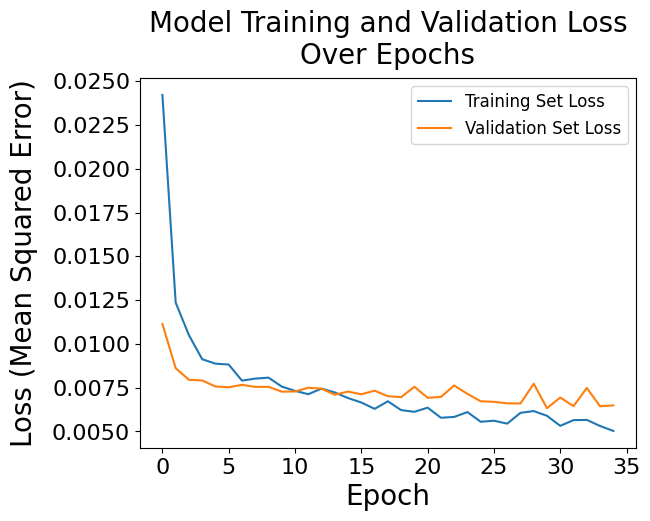

This plot visualizes both the training and validation Mean Squared Error (MSE) over each epoch.
Comparing these two lines helps to identify potential overfitting (where training loss continues to decrease but validation loss starts to increase) or underfitting.


In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation loss values together
plt.plot(history.history['loss'], label='Training Set Loss')
plt.plot(history.history['val_loss'], label='Validation Set Loss')
plt.title('Model Training and Validation Loss\nOver Epochs', pad = 10, fontsize = 20)
plt.ylabel('Loss (Mean Squared Error)', fontsize = 20, labelpad=10)
plt.xlabel('Epoch', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(loc='upper right', fontsize=12)
plt.show()

print("This plot visualizes both the training and validation Mean Squared Error (MSE) over each epoch.")
print("Comparing these two lines helps to identify potential overfitting (where training loss continues to decrease but validation loss starts to increase) or underfitting.")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


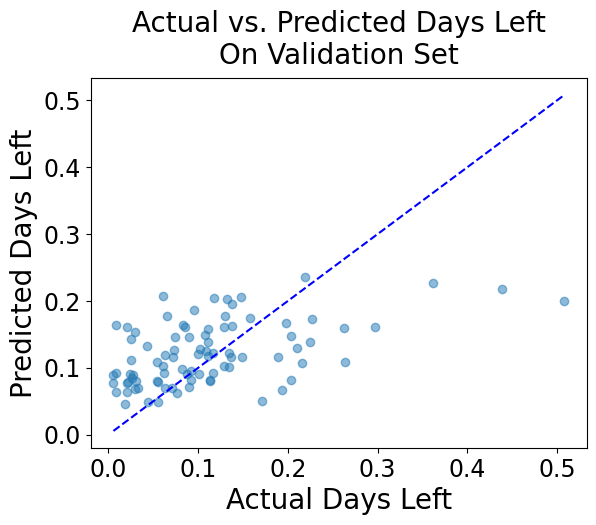

The plot above shows the actual vs. predicted 'daysLeft' values for the validation set.
A perfect model would have all points lying on the red dashed line (y=x).


In [ ]:
import matplotlib.pyplot as plt

# Make predictions on the validation set
y_pred = model.predict(X_val)

# Flatten y_val (true values) and y_pred (predicted values) for plotting
y_val_flat = y_val.flatten()
y_pred_flat = y_pred.flatten()

# Create the actual vs. predicted plot
plt.scatter(y_val_flat, y_pred_flat, alpha=0.5)
plt.title('Actual vs. Predicted Days Left\nOn Validation Set', pad = 10, fontsize=20)
plt.xlabel('Actual Days Left', fontsize=20)
plt.ylabel('Predicted Days Left', fontsize=20)
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)

# Add a line for perfect prediction (y=x)
plt.plot([min(y_val_flat), max(y_val_flat)], [min(y_val_flat), max(y_val_flat)], 'b--')

plt.show()

print("The plot above shows the actual vs. predicted 'daysLeft' values for the validation set.")
print("A perfect model would have all points lying on the red dashed line (y=x).")

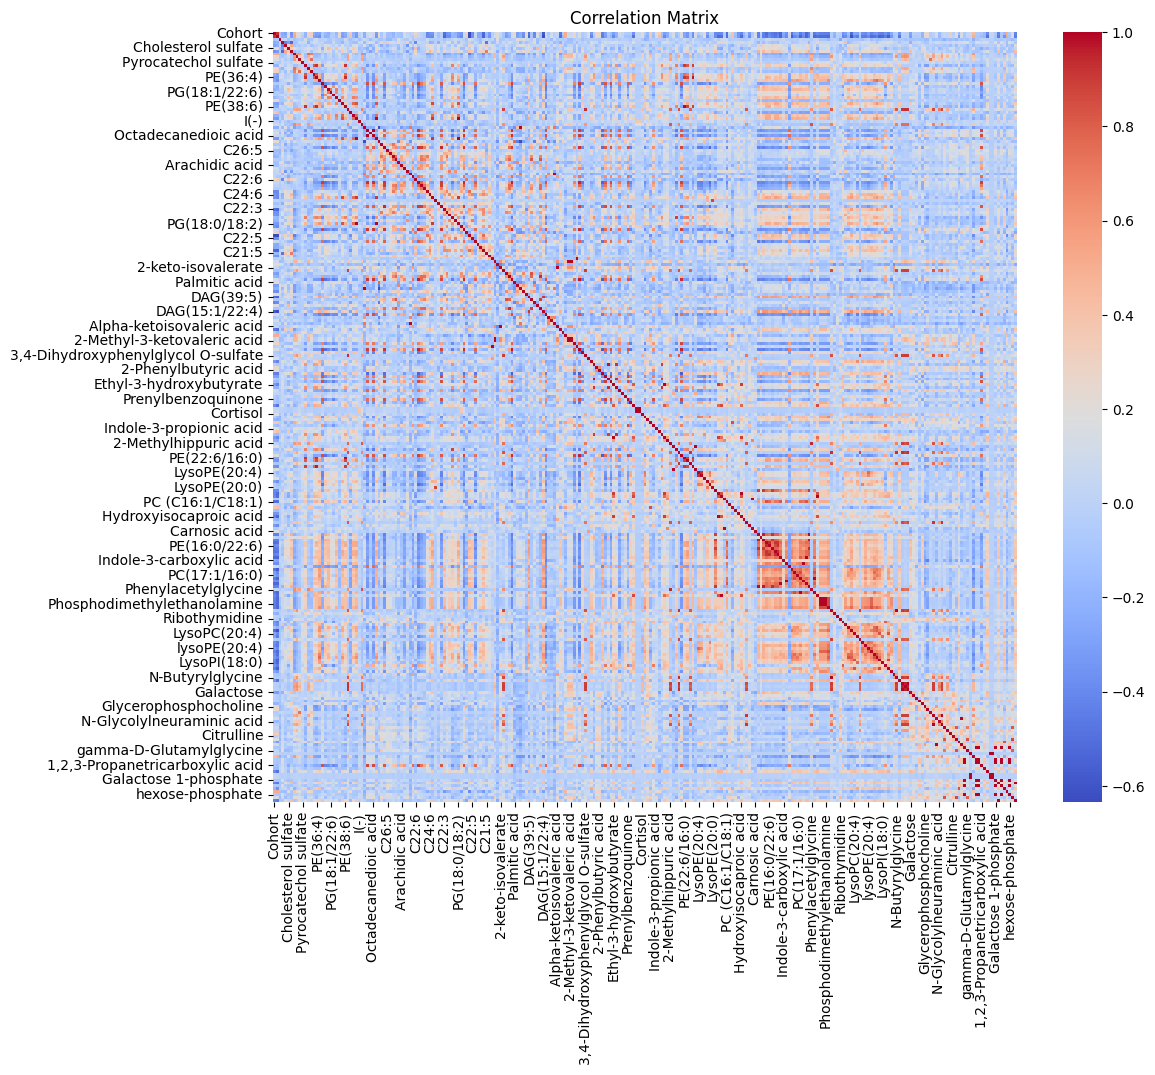

In [ ]:
# Checking for correlation between features
plt.figure(figsize=(12,10))
sns.heatmap(data.corr(), cmap = 'coolwarm', )
plt.title('Correlation Matrix')
plt.show()
# Note that not all the feature names are listed
# Note that most features do not appear to be correlated so we are good